# Extended Cooling Tail

In [1]:
from snewpy.models.ccsn import Nakazato_2013
from snewpy.models.extended import ExtendedModel
from snewpy.flavor import ThreeFlavor

from astropy import units as u

import numpy as np
import matplotlib.pyplot as plt

## Model Initialization

Let's use a model from the `Nakazato_2013` family of simulations. There are many model parameters to choose from:

In [2]:
Nakazato_2013.param

{'progenitor_mass': <Quantity [13., 20., 30., 50.] solMass>,
 'revival_time': <Quantity [  0., 100., 200., 300.] ms>,
 'metallicity': [0.02, 0.004],
 'eos': ['LS220', 'shen', 'togashi']}

Since there are many valid and invalid combinations of parameters available, we will generate a list of valid parameters using the class function `get_param_combinations` and then select one of the particular models for plotting.

It is not really important which model we choose, so we'll pick a large metallicity model (high $Z$).

In [3]:
highZ_models = list(params for params in Nakazato_2013.get_param_combinations() if params['metallicity'] == 0.02)

This should be equivalent to the initialization:
```
model = Nakazato_2013(progenitor_mass=20<<u.solMass, revival_time=100<<u.ms, metallicity=0.02, eos='shen')
```

In [4]:
model_params = highZ_models[3]
model = Nakazato_2013(**model_params)
model

**Nakazato_2013 Model**: nakazato-shen-z0.02-t_rev100ms-s20.0.fits

|Parameter|Value|
|:--------|:----:|
|Progenitor mass | $20$ $\mathrm{M_{\odot}}$|
|Revival time | $100$ $\mathrm{ms}$|
|Metallicity | 0.02 |
|EOS | shen |

Plot the model neutrino luminosity versus time.

(391, 3)


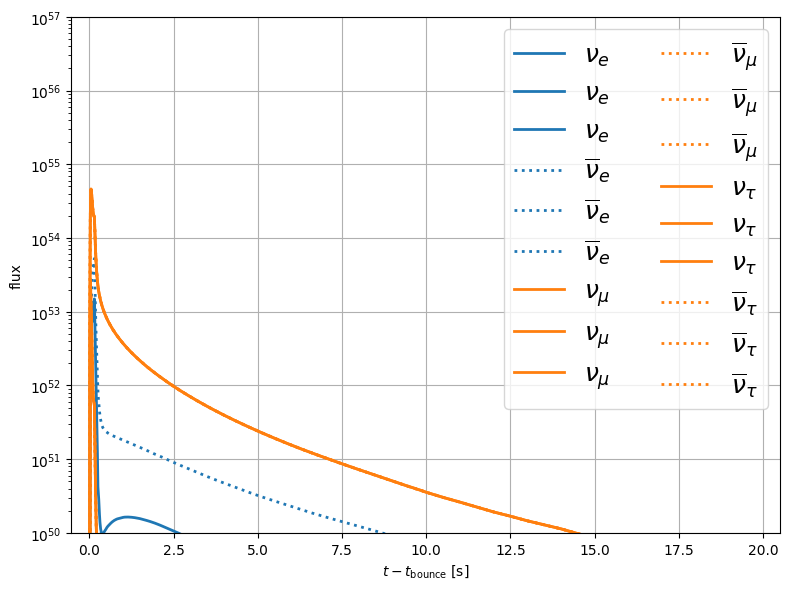

In [5]:
energy = np.linspace(0,100,3) * u.MeV
times = model.get_time()
spectrum = model.get_initial_spectra(t=times, E=energy)
spectrum2 = model._get_initial_spectra_dict(t=times, E=energy)
print(spectrum2[ThreeFlavor.NU_E].shape)

fig, ax = plt.subplots(1, figsize=(8,6), tight_layout=False)
for flavor in ThreeFlavor:
    ax.plot(times, spectrum[flavor].array.squeeze(),
            label=flavor.to_tex(),
            color = 'C0' if flavor.is_electron else 'C1',
            ls = '-' if flavor.is_neutrino else ':',
            lw = 2 )

ax.set(xlim=( (times[0]-0.5*u.s).value , (times[-1]+0.5*u.s).value ),
       xlabel=r'$t-t_{\rm bounce}$ [s]',
       ylabel=r'flux',
       yscale='log',
       ylim=(1e50,1e57))
ax.grid()
ax.legend(loc='upper right', ncol=2, fontsize=18);

In [6]:
ext_model = ExtendedModel(model)

In [9]:

ext_times = np.linspace(times[0],2*times[-1],500)
t_ext =  ext_times > model.time[-1]
print(ext_model.get_extended_time_dependence(t_ext))

ext_spectrum = ext_model.get_initial_spectra(t=ext_times, E=energy)

fig, ax = plt.subplots(1, figsize=(8,6), tight_layout=False)
for flavor in ThreeFlavor:
    ax.plot(ext_times, ext_spectrum[flavor].array.squeeze(),
            label=flavor.to_tex(),
            color = 'C0' if flavor.is_electron else 'C1',
            ls = '-' if flavor.is_neutrino else ':',
            lw = 2 )

ax.set(xlim=( (times[0]-0.5*u.s).value , (times[-1]+0.5*u.s).value ),
       xlabel=r'$t-t_{\rm bounce}$ [s]',
       ylabel=r'flux',
       yscale='log',
       ylim=(1e50,1e57))
ax.grid()
ax.legend(loc='upper right', ncol=2, fontsize=18);

[        inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         inf         inf         inf   

/home/jpknelle/.local/lib/python3.12/site-packages/snewpy/models/extended.py:69: UserWarning: Extended luminosity model not applicable to early times
  warn("Extended luminosity model not applicable to early times")
/home/jpknelle/.local/lib/python3.12/site-packages/snewpy/models/extended.py:71: RuntimeWarning: divide by zero encountered in power
  return self.A * times**self.k * np.exp(-(times/self.tau_c).value**self.alpha)
/home/jpknelle/.local/lib/python3.12/site-packages/numpy/_core/numeric.py:989: RuntimeWarning: invalid value encountered in multiply
  return multiply(a.ravel()[:, newaxis], b.ravel()[newaxis, :], out)


UnitConversionError: '1 / erg' and '1 / (erg s)' are not convertible